In [65]:
import pandas as pd
from sklearn import cluster
from config import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [66]:
# Reading WQ data
load_metrics = pd.read_csv(OUTPUT_filepath+'S-curve-metrics.csv')
load_metrics['STREAM_ID'] = 'STREAM-gauge-' + load_metrics['Gauge'].astype(str)

# Move STREAM_ID, year, month to the front
front = ['STREAM_ID', 'year', 'month']
load_metrics.drop(columns='Unnamed: 0', inplace=True)
load_metrics = load_metrics[front + [c for c in load_metrics.columns if c not in front]]

# Keep everything up to and including CAPE, drop the rest
cape_idx = load_metrics.columns.get_loc('acronym')
load_metrics = load_metrics.iloc[:, :cape_idx + 1]

load_metrics.head(2)

,STREAM_ID,year,month,Gauge,water_year,max_yield,min_yield,month_of_max_yield,month_of_min_yield,Magnitude,Time,site_name,acronym
0,STREAM-gauge-308,2007,10,308,2008,1.019798,0.070295,7,1,0.949503,6,Mississippi River,LA
1,STREAM-gauge-308,2007,10,308,2008,1.019798,0.070295,7,1,0.949503,6,Mississippi River,LA


In [67]:
static_data = pd.read_csv(OUTPUT_filepath+'static_MRB_basin_characteristics.csv')
static_data.head(2)

,STREAM_ID,ari_ix_sav,ppd_pk_sav,rdd_mk_sav,gwt_cm_sav,bfi,slp_dg_sav,wwtp_yield_m3_d_km2,pct_tile_drained,septic_density_km2,AU_density_mean,cons_conser_till_pct,cons_cover_crop_pct,cons_comb_no_conven_till_pct,silt_clay_pct,kSat_log10_cmhr,no3_tw_ave,nh4_tw_ave,fertnkg_ave,fertpkg_ave,manurenkg_ave,manurepkg_ave,irrig_pct_ave
0,STREAM-gauge-2203,0.498293,9.528330,158.505083,347.308883,43.337179,2.888017,3.491718,0.852624,1.603344,18.900828,6.863557,0.791198,17.074749,58.717077,0.156942,4.195141,3.009861,21.979493,3.390321,10.015796,3.140135,3.800100
1,STREAM-gauge-2804,0.523291,6.462265,147.091872,225.871288,34.527439,1.166720,2.028770,0.480450,1.843209,24.336805,13.631193,1.355008,32.665327,72.292313,0.132478,5.813645,4.417000,42.672251,6.194499,13.168235,3.953505,11.485446


In [68]:
# Temporal properties
temporal_data = pd.read_csv(OUTPUT_filepath+'met_anthro_lulc_river.csv')
temporal_data.rename({'DateTime_x':'DateTime'}, axis=1, inplace=True)
temporal_data.drop(columns = ['Unnamed: 0', 'DateTime_y'], inplace=True)
temporal_data.head(2)

,STREAM_ID,DateTime,APCP_surface_total,SPFH_2maboveground_mean,TMP_2maboveground_mean,site_name,catchmentarea_km2,State,river,Month,Year,Water_Year,Water_Month,so4_tw,cl_tw,no3_tw,na_tw,k_tw,ca_tw,mg_tw,nh4_tw,salt_pound,nfer,pfer,fertnkg,fertpkg,manurenkg,manurepkg,irrig,Open Water,Perennial Ice/Snow,Developed Open Space,Developed Low Intensity,Developed Medium Intensity,Developed High Intensity,Barren Land,Deciduous Forest,Evergreen Forest,Mixed Forest,Shrub/Scrub,Grassland/Herbaceous,Pasture/Hay,Cultivated Crops,Woody Wetlands,Emergent Herbaceous Wetlands
0,STREAM-gauge-2203,2013-10-31,70.121323,0.003999,279.467963,"Missouri River at Hermann, MO",1.277917e+06,MO,Missouri River,10,2013,2014,1,3.691841,0.47989,5.068727,0.329353,0.211311,1.980508,0.210343,3.142507,1035.873954,7.602587,1.036206,20.303691,3.220972,9.236781,2.868724,0.038424,0.010477,0.000045,0.018716,0.012507,0.003307,0.000619,0.005628,0.028743,0.053739,0.001805,0.150995,0.363346,0.062115,0.267554,0.006217,0.014188
1,STREAM-gauge-2203,2013-11-30,21.150725,0.002817,272.661447,"Missouri River at Hermann, MO",1.277917e+06,MO,Missouri River,11,2013,2014,2,3.691841,0.47989,5.068727,0.329353,0.211311,1.980508,0.210343,3.142507,1035.873954,7.602587,1.036206,20.303691,3.220972,9.236781,2.868724,0.038424,0.010477,0.000045,0.018716,0.012507,0.003307,0.000619,0.005628,0.028743,0.053739,0.001805,0.150995,0.363346,0.062115,0.267554,0.006217,0.014188


In [69]:
temporal_data.columns

Index(['STREAM_ID', 'DateTime', 'APCP_surface_total',
       'SPFH_2maboveground_mean', 'TMP_2maboveground_mean', 'site_name',
       'catchmentarea_km2', 'State', 'river', 'Month', 'Year', 'Water_Year',
       'Water_Month', 'so4_tw', 'cl_tw', 'no3_tw', 'na_tw', 'k_tw', 'ca_tw',
       'mg_tw', 'nh4_tw', 'salt_pound', 'nfer', 'pfer', 'fertnkg', 'fertpkg',
       'manurenkg', 'manurepkg', 'irrig', 'Open Water', 'Perennial Ice/Snow',
       'Developed Open Space', 'Developed Low Intensity',
       'Developed Medium Intensity', 'Developed High Intensity', 'Barren Land',
       'Deciduous Forest', 'Evergreen Forest', 'Mixed Forest', 'Shrub/Scrub',
       'Grassland/Herbaceous', 'Pasture/Hay', 'Cultivated Crops',
       'Woody Wetlands', 'Emergent Herbaceous Wetlands'],
      dtype='str')

In [70]:
# Crop types
crop_type_data = pd.read_csv(OUTPUT_filepath+'MRB_compiled_crop_type.csv')

keep = ['STREAM_ID', 'year', 'Corn', 'Winter_Wheat', 'Other_Hay_Non_Alfalfa', 'Soybeans', 'Fallow_Idle_Cropland']
crop_type_data = crop_type_data[keep]
crop_type_data.head(2)

,STREAM_ID,year,Corn,Winter_Wheat,Other_Hay_Non_Alfalfa,Soybeans,Fallow_Idle_Cropland
0,STREAM-gauge-2891,2015,35.495050,0.221891,0.282228,34.727504,0.206549
1,STREAM-gauge-2886,2015,49.294567,0.146058,0.027959,42.589149,0.033886


In [71]:
crop_type_data.columns

Index(['STREAM_ID', 'year', 'Corn', 'Winter_Wheat', 'Other_Hay_Non_Alfalfa',
       'Soybeans', 'Fallow_Idle_Cropland'],
      dtype='str')

In [72]:
# LU processing 
avg_cols = [
    'so4_tw', 'cl_tw', 'no3_tw', 'na_tw', 'k_tw', 'ca_tw', 'mg_tw', 'nh4_tw',
    'salt_pound', 'nfer', 'pfer', 'fertnkg', 'fertpkg', 'manurenkg', 'manurepkg',
    'irrig', 'Open Water', 'Perennial Ice/Snow', 'Developed Open Space',
    'Developed Low Intensity', 'Developed Medium Intensity', 'Developed High Intensity',
    'Barren Land', 'Deciduous Forest', 'Evergreen Forest', 'Mixed Forest',
    'Shrub/Scrub', 'Grassland/Herbaceous', 'Pasture/Hay', 'Cultivated Crops',
    'Woody Wetlands', 'Emergent Herbaceous Wetlands'
]

temporal_ave = temporal_data.groupby('STREAM_ID')[avg_cols].mean().reset_index()
temporal_data.head(2)

,STREAM_ID,DateTime,APCP_surface_total,SPFH_2maboveground_mean,TMP_2maboveground_mean,site_name,catchmentarea_km2,State,river,Month,Year,Water_Year,Water_Month,so4_tw,cl_tw,no3_tw,na_tw,k_tw,ca_tw,mg_tw,nh4_tw,salt_pound,nfer,pfer,fertnkg,fertpkg,manurenkg,manurepkg,irrig,Open Water,Perennial Ice/Snow,Developed Open Space,Developed Low Intensity,Developed Medium Intensity,Developed High Intensity,Barren Land,Deciduous Forest,Evergreen Forest,Mixed Forest,Shrub/Scrub,Grassland/Herbaceous,Pasture/Hay,Cultivated Crops,Woody Wetlands,Emergent Herbaceous Wetlands
0,STREAM-gauge-2203,2013-10-31,70.121323,0.003999,279.467963,"Missouri River at Hermann, MO",1.277917e+06,MO,Missouri River,10,2013,2014,1,3.691841,0.47989,5.068727,0.329353,0.211311,1.980508,0.210343,3.142507,1035.873954,7.602587,1.036206,20.303691,3.220972,9.236781,2.868724,0.038424,0.010477,0.000045,0.018716,0.012507,0.003307,0.000619,0.005628,0.028743,0.053739,0.001805,0.150995,0.363346,0.062115,0.267554,0.006217,0.014188
1,STREAM-gauge-2203,2013-11-30,21.150725,0.002817,272.661447,"Missouri River at Hermann, MO",1.277917e+06,MO,Missouri River,11,2013,2014,2,3.691841,0.47989,5.068727,0.329353,0.211311,1.980508,0.210343,3.142507,1035.873954,7.602587,1.036206,20.303691,3.220972,9.236781,2.868724,0.038424,0.010477,0.000045,0.018716,0.012507,0.003307,0.000619,0.005628,0.028743,0.053739,0.001805,0.150995,0.363346,0.062115,0.267554,0.006217,0.014188


In [73]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [74]:
# ----------------------------------------------------------------------------
# CONFIG  — edit these to match your columns / choices
# ----------------------------------------------------------------------------
CONFIG = {
    # keys
    "ID_COL": "STREAM_ID",
    "LM_YEAR_COL": "year",        # year column in load_metrics
    "TEMPORAL_YEAR_COL": "Year",  # 'Year' or 'Water_Year'
    "CROP_YEAR_COL": "year",

    # features k-means clusters on (from load_metrics)
    "CLUSTER_FEATURES": [
        "max_yield", "min_yield", "Magnitude", "Time",
        "month_of_max_yield", "month_of_min_yield",
    ],
    "MONTH_COLS": ["month_of_max_yield", "month_of_min_yield"],
    "CYCLIC_MONTHS": True,        # encode month cols as sin/cos

    # k selection
    "K_RANGE": range(2, 11),
    "K_OVERRIDE": None,           # set an int to skip auto-selection
    "RANDOM_STATE": 42,

    # temporal -> annual aggregation (default mean; listed cols overridden)
    "TEMPORAL_AGG": {"APCP_surface_total": "sum"},

    # which columns belong to which property group (must exist post-merge)
    "CATEGORIES": {
        "climate": ["APCP_surface_total", "TMP_2maboveground_mean",
                    "SPFH_2maboveground_mean", "ari_ix_sav"],
        "soil": ["silt_clay_pct", "kSat_log10_cmhr", "slp_dg_sav",
                 "gwt_cm_sav", "bfi"],
        "crop": ["Corn", "Winter_Wheat", "Other_Hay_Non_Alfalfa",
                 "Soybeans", "Fallow_Idle_Cropland"],
        
        # available but off by default — uncomment to profile:
         "management": ["pct_tile_drained", "irrig_pct_ave",
                        "cons_conser_till_pct", "cons_cover_crop_pct",
                        "fertnkg_ave", "fertpkg_ave", "manurenkg_ave",
                        "manurepkg_ave", "AU_density_mean",
                        "wwtp_yield_m3_d_km2", "septic_density_km2"],
        
         "landuse": ["Cultivated Crops", "Pasture/Hay", "Deciduous Forest",
                     "Developed Low Intensity", "Woody Wetlands"],
    },

    "OUTDIR": "cluster_outputs",
}

In [75]:
# ----------------------------------------------------------------------------
# 1. Build the clustering feature matrix
# ----------------------------------------------------------------------------
def build_features(load_metrics, cfg):
    cols = cfg["CLUSTER_FEATURES"]
    X = load_metrics[cols].copy()

    if cfg["CYCLIC_MONTHS"]:
        for m in cfg["MONTH_COLS"]:
            X[f"{m}_sin"] = np.sin(2 * np.pi * load_metrics[m] / 12.0)
            X[f"{m}_cos"] = np.cos(2 * np.pi * load_metrics[m] / 12.0)
        X = X.drop(columns=cfg["MONTH_COLS"])

    return X

# ----------------------------------------------------------------------------
# 2. Choose k: elbow (inertia) + silhouette, with a dependency-free knee finder
# ----------------------------------------------------------------------------
def _knee(ks, inertia):
    """Point of maximum distance from the chord between endpoints (Kneedle-lite)."""
    ks = np.asarray(ks, float)
    y = np.asarray(inertia, float)
    x0, x1, y0, y1 = ks[0], ks[-1], y[0], y[-1]
    # perpendicular distance of each point to the endpoint chord
    num = np.abs((y1 - y0) * ks - (x1 - x0) * y + x1 * y0 - y1 * x0)
    den = np.hypot(y1 - y0, x1 - x0)
    return int(ks[np.argmax(num / den)])


def choose_k(Xs, cfg):
    ks = [k for k in cfg["K_RANGE"] if k < Xs.shape[0]]
    inertia, sil = [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10,
                    random_state=cfg["RANDOM_STATE"]).fit(Xs)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(Xs, km.labels_))

    k_elbow = _knee(ks, inertia)
    k_sil = ks[int(np.argmax(sil))]
    k = cfg["K_OVERRIDE"] or k_elbow

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(ks, inertia, "o-")
    ax[0].axvline(k_elbow, ls="--", c="crimson", label=f"elbow k={k_elbow}")
    ax[0].set(xlabel="k", ylabel="inertia", title="Elbow")
    ax[0].legend()
    ax[1].plot(ks, sil, "o-", c="teal")
    ax[1].axvline(k_sil, ls="--", c="crimson", label=f"peak k={k_sil}")
    ax[1].set(xlabel="k", ylabel="silhouette", title="Silhouette")
    ax[1].legend()
    fig.tight_layout()
    fig.savefig(os.path.join(cfg["OUTDIR"], "00_k_selection.png"), dpi=150)
    plt.show()

    print(f"elbow suggests k={k_elbow}; silhouette peaks at k={k_sil}; using k={k}")
    return k

In [76]:
# ----------------------------------------------------------------------------
# 3. Fit final clusters, attach labels to surviving load_metrics rows
# ----------------------------------------------------------------------------
def fit_clusters(load_metrics, cfg):
    X = build_features(load_metrics, cfg)
    keep = X.dropna().index
    dropped = len(X) - len(keep)
    if dropped:
        print(f"dropped {dropped} station-years with NaNs in cluster features")

    Xs = StandardScaler().fit_transform(X.loc[keep])
    k = choose_k(Xs, cfg)
    labels = KMeans(n_clusters=k, n_init=10,
                    random_state=cfg["RANDOM_STATE"]).fit_predict(Xs)

    lm = load_metrics.loc[keep].copy()
    lm["cluster"] = labels
    return lm, k

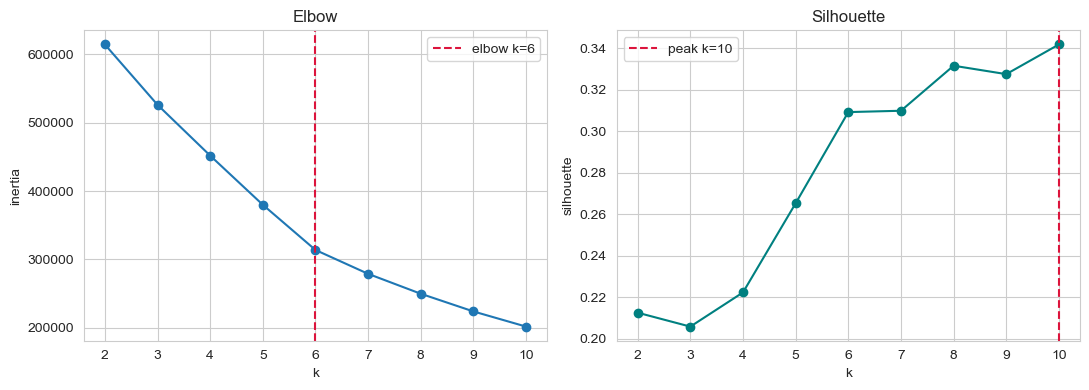

elbow suggests k=6; silhouette peaks at k=10; using k=6
cluster sizes (station-years):
cluster
0     5122
1    26615
2    26696
3     5125
4     2811
5    22944
Name: count, dtype: int64


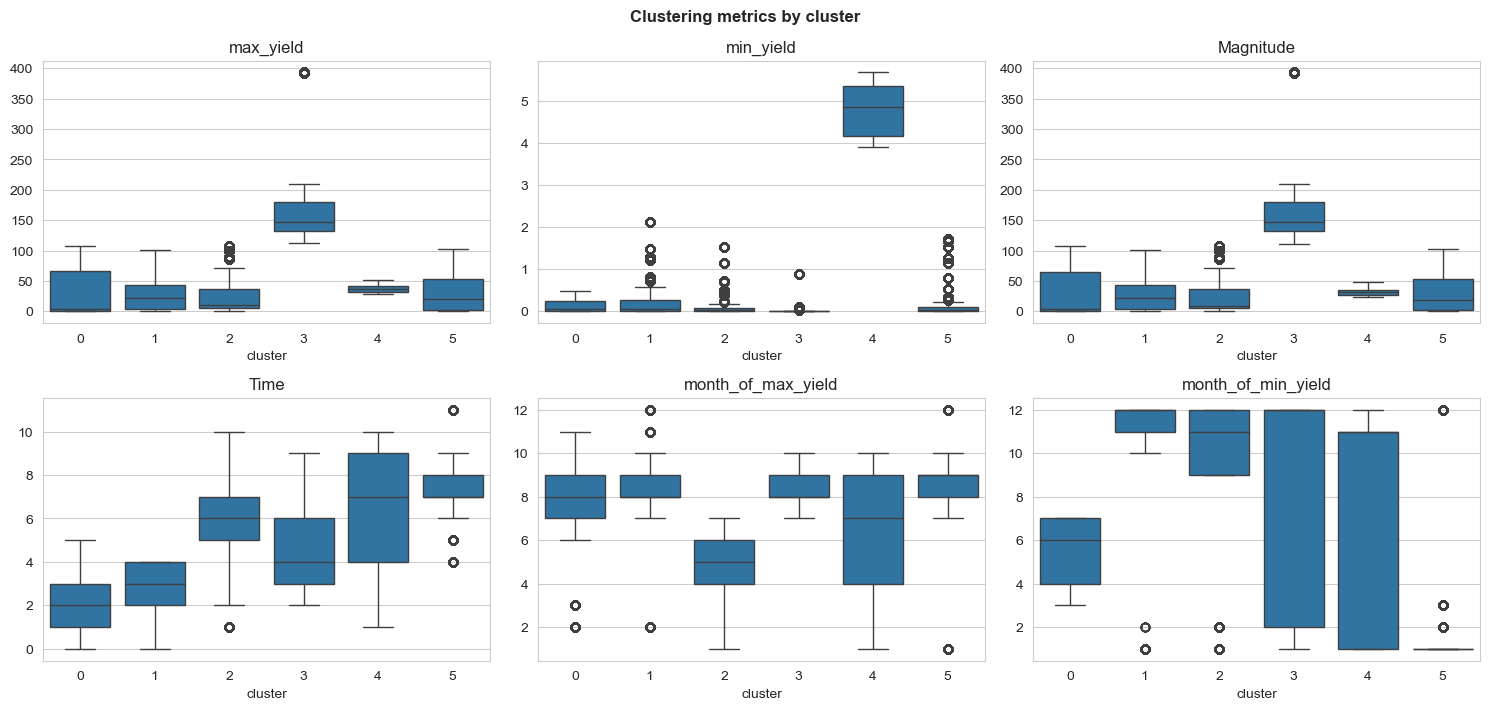

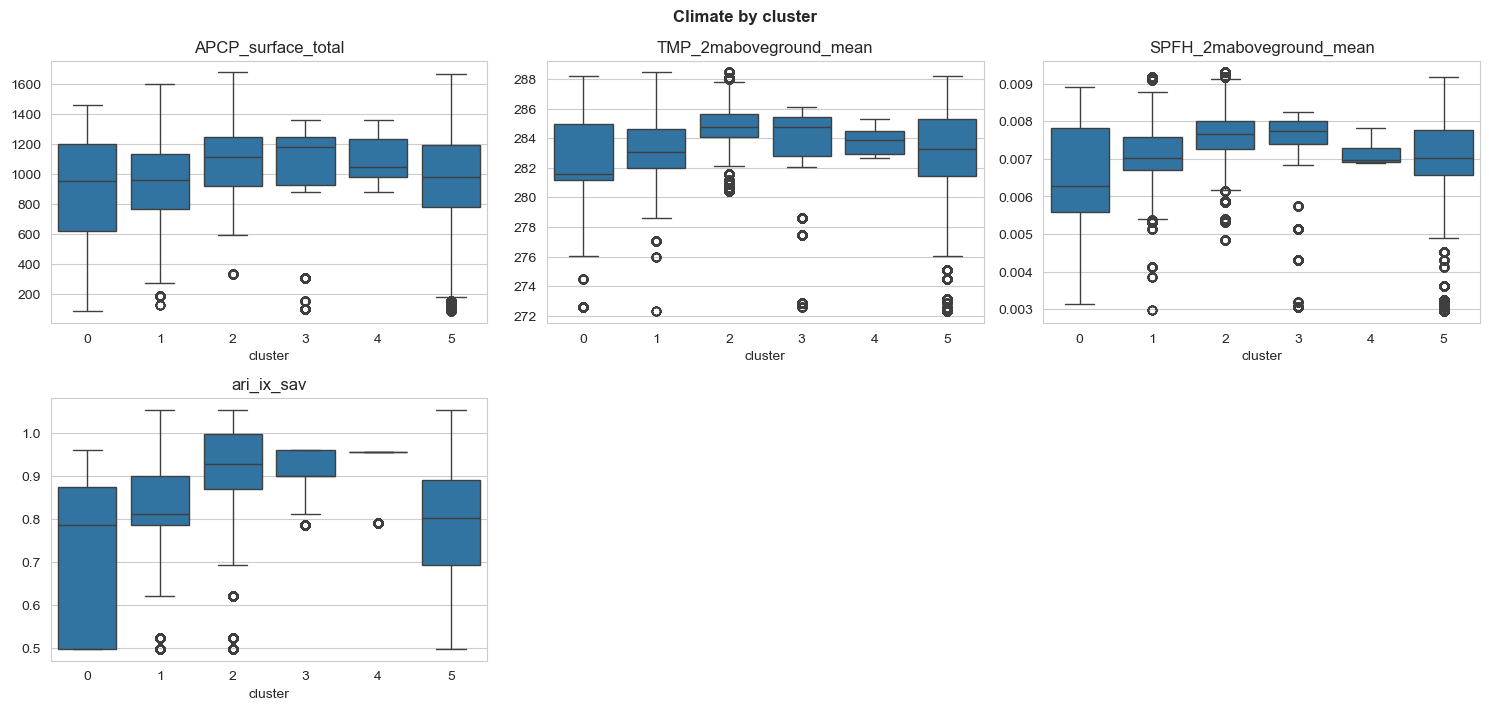

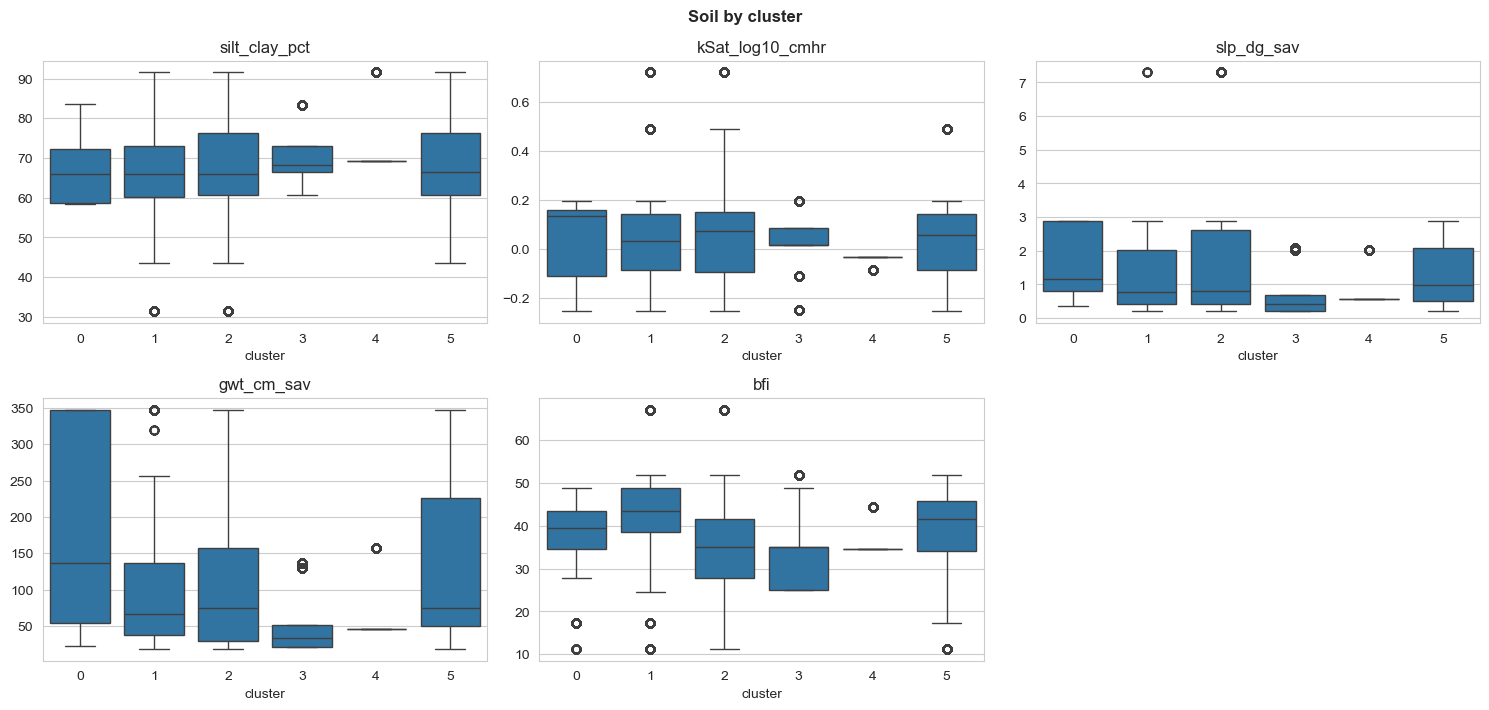

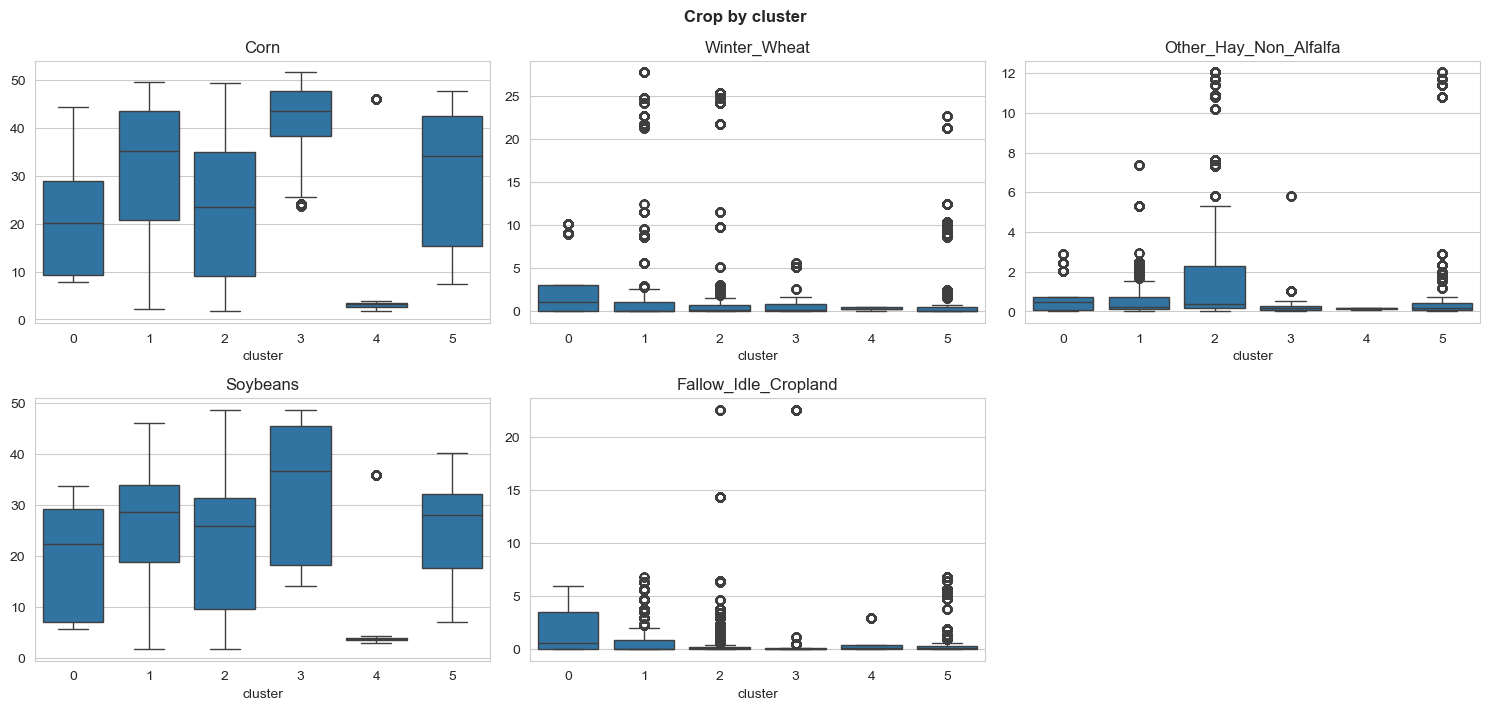

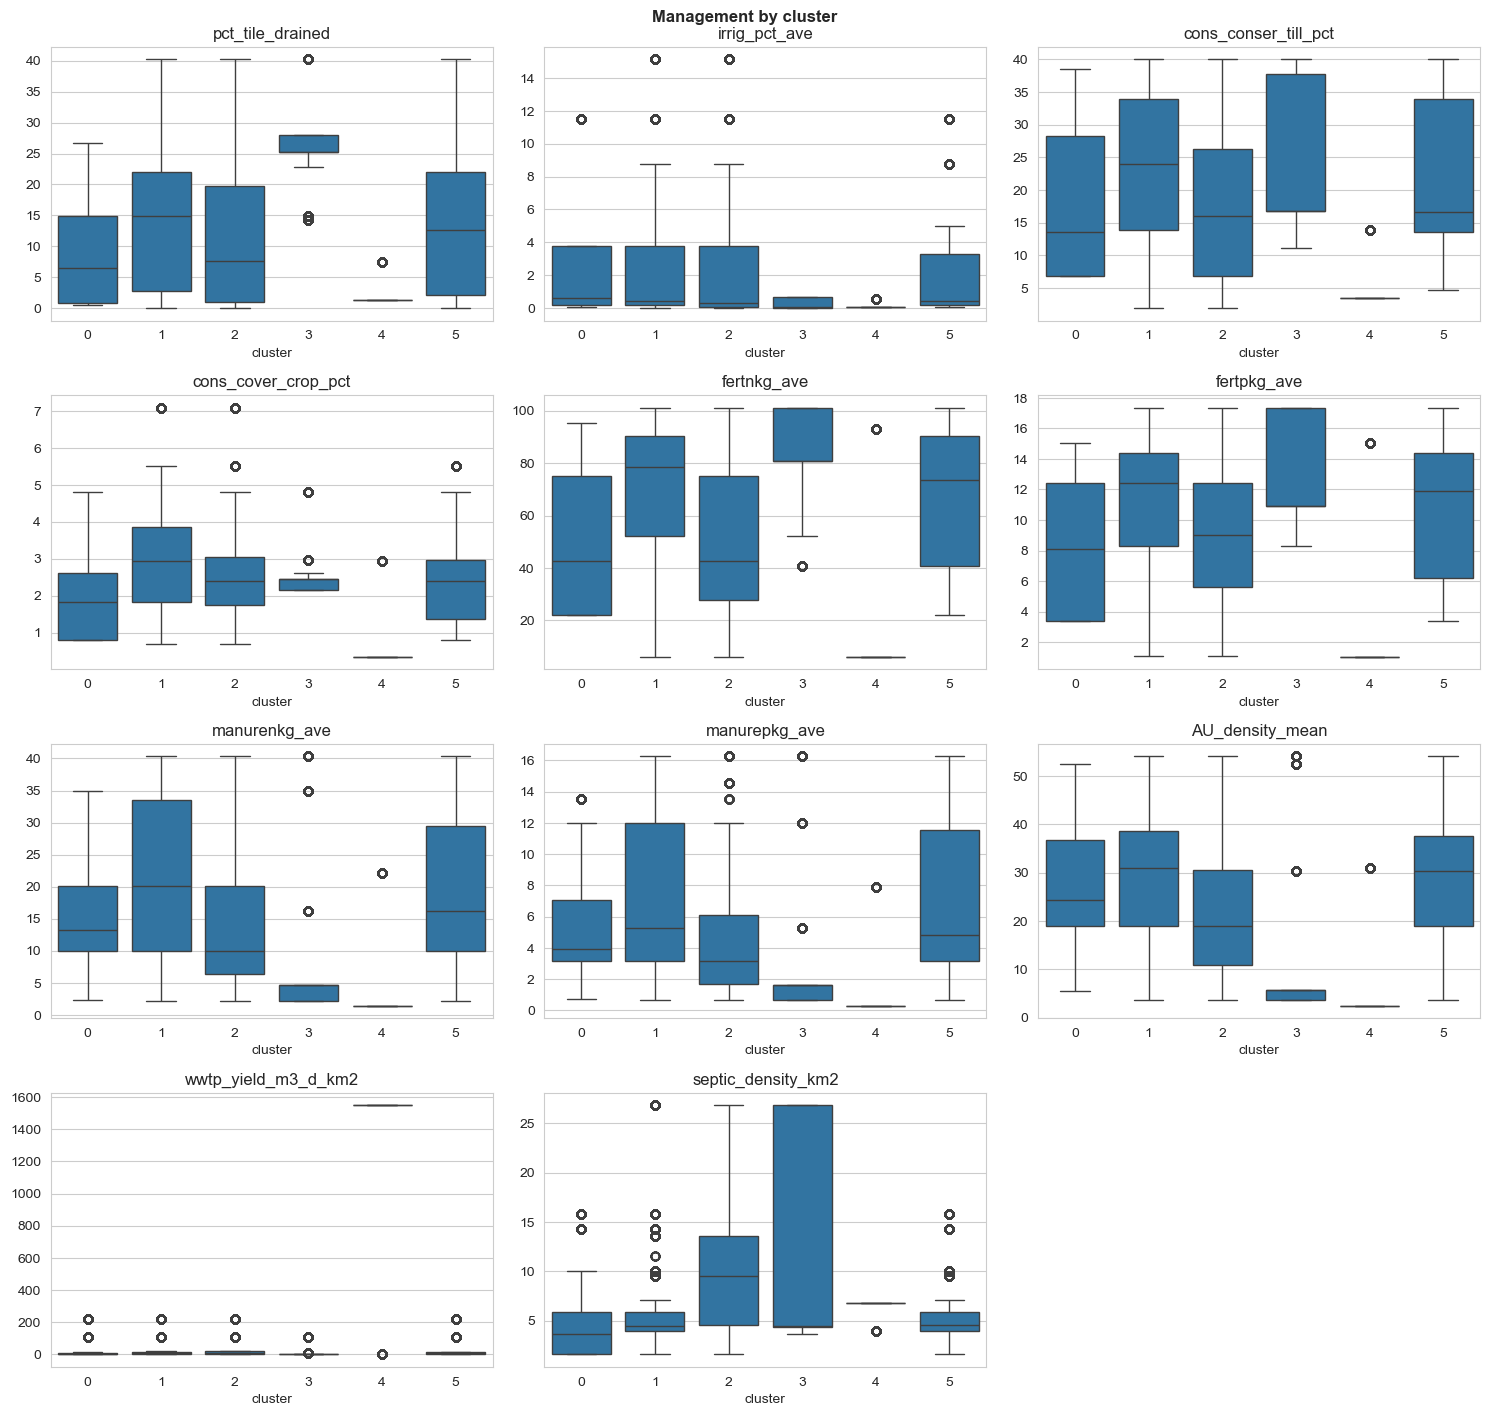

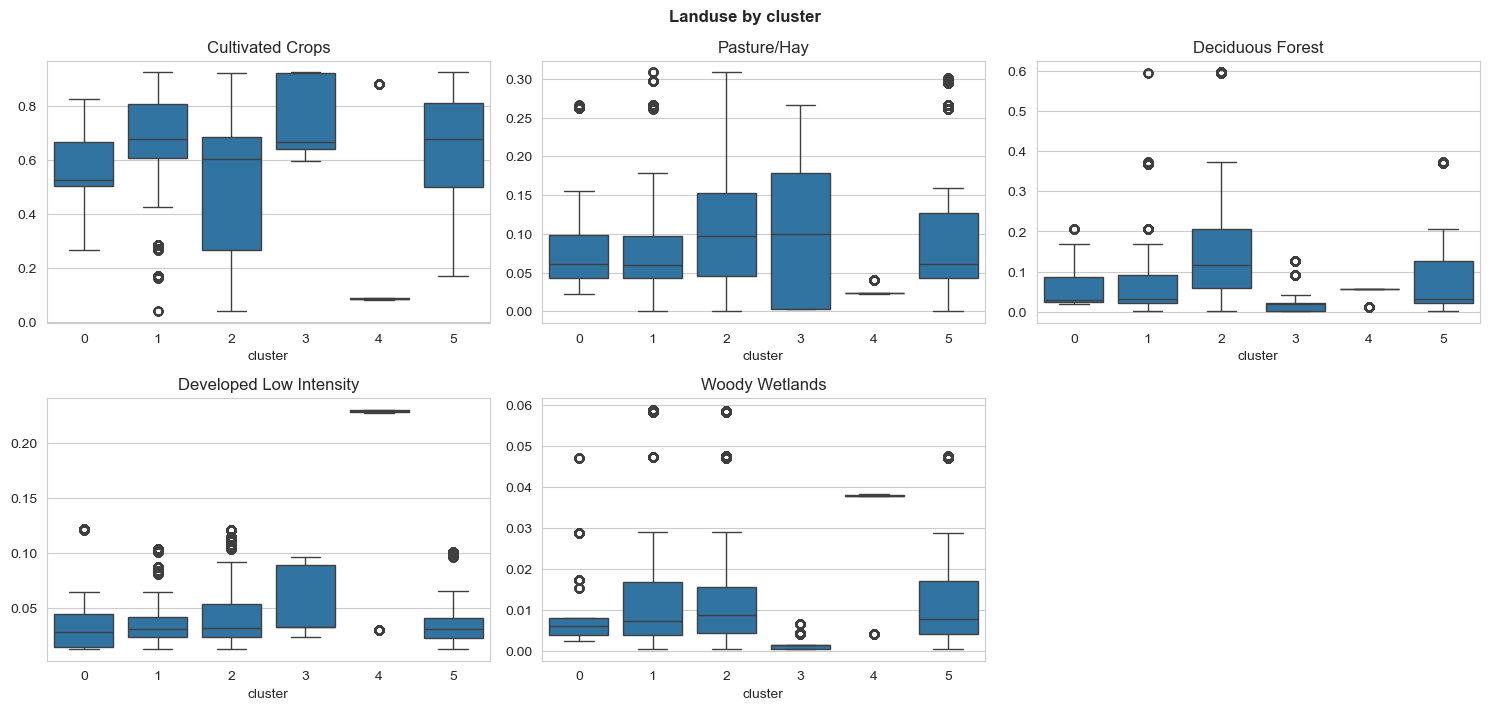

In [77]:
# ----------------------------------------------------------------------------
# 4. Merge cluster labels onto every property source, keyed (STREAM_ID, year)
# ----------------------------------------------------------------------------
def attach_clusters(lm, static_data, temporal_data, crop_type_data, cfg):
    ID, Y = cfg["ID_COL"], "YEAR"

    labels = lm[[ID, cfg["LM_YEAR_COL"], "cluster"]].rename(
        columns={cfg["LM_YEAR_COL"]: Y})

    # load metrics themselves (for the clustering-metric boxplots)
    metrics = lm[[ID, cfg["LM_YEAR_COL"]] + cfg["CLUSTER_FEATURES"] + ["cluster"]]

    # static: constant per station -> broadcast across years
    df = labels.merge(static_data, on=ID, how="left")

    # temporal: collapse to one row per (station, year), then merge
    tcol = cfg["TEMPORAL_YEAR_COL"]
    num = temporal_data.select_dtypes("number").columns.difference([tcol])
    agg = {c: "mean" for c in num}
    agg.update({c: v for c, v in cfg["TEMPORAL_AGG"].items() if c in num})
    tann = (temporal_data.groupby([ID, tcol]).agg(agg).reset_index()
            .rename(columns={tcol: Y}))
    df = df.merge(tann, on=[ID, Y], how="left")

    # crop: already (station, year)
    crop = crop_type_data.rename(columns={cfg["CROP_YEAR_COL"]: Y})
    df = df.merge(crop, on=[ID, Y], how="left")

    return df, metrics


# ----------------------------------------------------------------------------
# 5. Boxplots
# ----------------------------------------------------------------------------
def _grid(df, params, title, path):
    params = [p for p in params if p in df.columns]
    if not params:
        print(f"skip '{title}': no columns present")
        return
    n = len(params)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows),
                             squeeze=False)
    for ax, p in zip(axes.ravel(), params):
        sns.boxplot(data=df, x="cluster", y=p, ax=ax)
        ax.set_title(p)
        ax.set_xlabel("cluster")
        ax.set_ylabel("")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


def plot_clustering_metrics(metrics, cfg):
    _grid(metrics, cfg["CLUSTER_FEATURES"],
          "Clustering metrics by cluster",
          os.path.join(cfg["OUTDIR"], "01_clustering_metrics.png"))


def plot_categories(analysis_df, cfg):
    for i, (name, cols) in enumerate(cfg["CATEGORIES"].items(), start=2):
        _grid(analysis_df, cols, f"{name.capitalize()} by cluster",
              os.path.join(cfg["OUTDIR"], f"{i:02d}_{name}.png"))


# ----------------------------------------------------------------------------
# 6. Summary statistics per cluster, per category
# ----------------------------------------------------------------------------
def summary_stats(analysis_df, metrics, cfg):
    def describe(df, cols):
        cols = [c for c in cols if c in df.columns]
        g = df.groupby("cluster")[cols].agg(
            ["count", "mean", "median", "std",
             lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
        g.columns = g.columns.set_levels(
            ["count", "mean", "median", "std", "q25", "q75"], level=1)
        return g

    out = {"clustering_metrics": describe(metrics, cfg["CLUSTER_FEATURES"])}
    for name, cols in cfg["CATEGORIES"].items():
        out[name] = describe(analysis_df, cols)

    for name, tbl in out.items():
        tbl.to_csv(os.path.join(cfg["OUTDIR"], f"stats_{name}.csv"))
    return out


# ----------------------------------------------------------------------------
# Orchestrator
# ----------------------------------------------------------------------------
def run_pipeline(load_metrics, static_data, temporal_data, crop_type_data,
                 cfg=CONFIG):
    os.makedirs(cfg["OUTDIR"], exist_ok=True)
    sns.set_style("whitegrid")

    lm, k = fit_clusters(load_metrics, cfg)
    analysis_df, metrics = attach_clusters(
        lm, static_data, temporal_data, crop_type_data, cfg)

    print("cluster sizes (station-years):")
    print(analysis_df["cluster"].value_counts().sort_index())

    plot_clustering_metrics(metrics, cfg)
    plot_categories(analysis_df, cfg)
    stats = summary_stats(analysis_df, metrics, cfg)

    return {"analysis_df": analysis_df, "metrics": metrics,
            "k": k, "summary_stats": stats}


if __name__ == "__main__":
    # expects the four DataFrames in scope, e.g. loaded above in a notebook
    results = run_pipeline(load_metrics, static_data, temporal_data,
                           crop_type_data, CONFIG)